In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy import stats

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
ERA5_path = '/glade/work/acruz/Caribbean_Heat_data/ERA5/'

In [3]:
RH = xr.open_dataset(ERA5_path+'RH_during_peak_HI.nc')
T  = xr.open_dataset(ERA5_path+'T_during_peak_HI.nc')
U  = xr.open_dataset(ERA5_path+'U10_during_peak_HI.nc')
V  = xr.open_dataset(ERA5_path+'V10_during_peak_HI.nc')
HI_dmax = xr.open_dataset(ERA5_path+'dailymax_HI.nc')

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
idate = '1981-09-30'
fdate = '2026-02-28'
HI_dmax = HI_dmax['HI_daily_max'].sel(time=slice(idate, fdate))
RH = RH['RH_during_HIdmax'].sel(time=slice(idate, fdate))
T = T['T_during_HIdmax'].sel(time=slice(idate, fdate))
U = U['U_during_HIdmax'].sel(time=slice(idate, fdate))
V = V['V_during_HIdmax'].sel(time=slice(idate, fdate))

In [5]:
#  mix u and v to a single dataset
UV = xr.merge([U, V], compat='equals')
UV

<xarray.Dataset> Size: 1GB
Dimensions:          (latitude: 82, longitude: 121, time: 16164)
Coordinates:
  * latitude         (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude        (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
  * time             (time) datetime64[ns] 129kB 1981-09-30 ... 2025-12-31
Data variables:
    U_during_HIdmax  (time, latitude, longitude) float32 642MB ...
    V_during_HIdmax  (time, latitude, longitude) float32 642MB ...

# monthly means

In [6]:
def me_mean(ds):
    meds = ds.resample(time='ME').mean()
    return meds


meHI_dmax = me_mean(HI_dmax)
meRH = me_mean(RH)
meT = me_mean(T)
meUV = me_mean(UV)

In [7]:
def C_to_F(t):
    F_ds = (t * 9/5) + 32
    return F_ds


def K_to_C(t):
    return (t - 273.15)

In [8]:
meT = C_to_F(K_to_C(meT))
meT

<xarray.DataArray 'T_during_HIdmax' (time: 534, latitude: 82, longitude: 121)> Size: 21MB
array([[[78.97199 , 79.01275 , 78.96705 , ..., 89.740295, 88.393814,
         86.18089 ],
        [79.1091  , 79.2216  , 79.249725, ..., 88.91956 , 86.296906,
         83.17844 ],
        [79.400894, 79.24269 , 79.13722 , ..., 84.31217 , 82.591324,
         82.496735],
        ...,
        [81.998726, 80.90042 , 81.00941 , ..., 78.39521 , 78.46552 ,
         78.4831  ],
        [82.23427 , 82.15341 , 80.76683 , ..., 78.4619  , 78.3038  ,
         78.31084 ],
        [82.325676, 82.33271 , 82.18153 , ..., 78.64427 , 78.60603 ,
         78.60603 ]],

       [[78.313965, 78.32418 , 78.336655, ..., 86.41633 , 85.65261 ,
         83.87799 ],
        [78.42982 , 78.45332 , 78.492874, ..., 85.80214 , 83.77851 ,
         81.63892 ],
        [78.53034 , 78.52699 , 78.57912 , ..., 82.88191 , 81.72972 ,
         81.76329 ],
...
        [69.46223 , 69.602905, 69.79819 , ..., 74.92413 , 74.83943 ,
         74.80735 ],
        [69.0042  , 69.1406  , 69.288475, ..., 74.7216  , 74.64448 ,
         74.585976],
        [68.56695 , 68.704605, 68.85759 , ..., 74.61789 , 74.55312 ,
         74.507805]],

       [[80.01399 , 80.25398 , 80.52738 , ..., 85.94765 , 85.14378 ,
         83.205956],
        [79.48154 , 79.76559 , 80.09413 , ..., 85.147354, 82.94135 ,
         80.17433 ],
        [78.871025, 79.19002 , 79.56278 , ..., 81.80443 , 80.27151 ,
         80.27904 ],
        ...,
        [70.00111 , 70.20408 , 70.400566, ..., 72.87996 , 72.81915 ,
         72.90254 ],
        [69.60873 , 69.80406 , 69.900635, ..., 72.550316, 72.597725,
         72.64996 ],
        [69.223   , 69.40867 , 69.45476 , ..., 72.23787 , 72.29686 ,
         72.36717 ]]], shape=(534, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-09-30 1981-10-31 ... 2026-02-28
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

# ERS selection

In [9]:
ERS = [4, 5, 6, 7]
ERS_HI = meHI_dmax.where(meHI_dmax.time.dt.month.isin(ERS), drop=True)
ERS_RH = meRH.where(meRH.time.dt.month.isin(ERS), drop=True)
ERS_T = meT.where(meT.time.dt.month.isin(ERS), drop=True)
ERS_UV = meUV.where(meUV.time.dt.month.isin(ERS), drop=True)

## HI and UV

In [11]:
ERS_HIme = ERS_HI.mean('time')
ERS_RHme = ERS_RH.mean('time')
ERS_Tme = ERS_T.mean('time')
ERS_UVme = ERS_UV.mean('time')

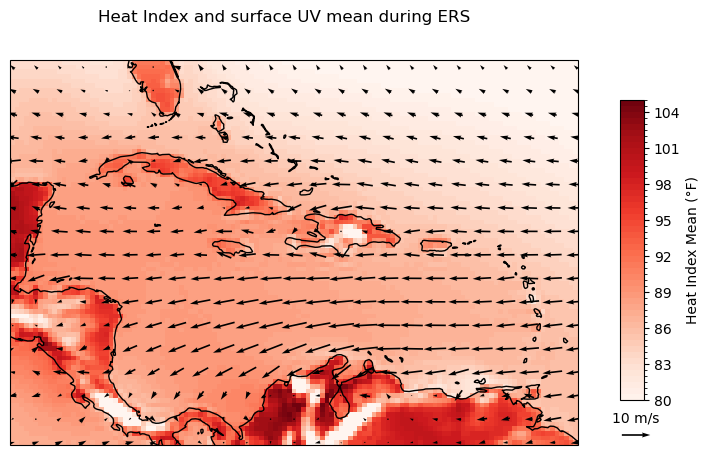

In [21]:
ERS_HIme_plot = ERS_HIme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(80, 105.5, 0.5), colors='Reds', subplot_kws={'projection': ccrs.PlateCarree()})

UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=200)

ERS_HIme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = ERS_HIme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HIme_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=10, label='10 m/s', labelpos='N', coordinates='figure')

plt.suptitle('Heat Index and surface UV mean during ERS')
plt.show()

### RH

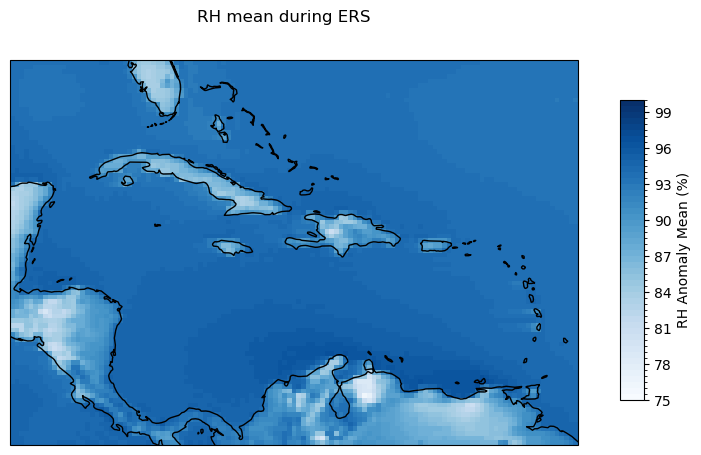

In [13]:
ERS_RHme_plot = ERS_RHme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(75, 100.5, 0.5), colors='Blues', subplot_kws={'projection': ccrs.PlateCarree()})

# UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
# UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=190)

ERS_RHme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = ERS_RHme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RHme_plot, cax=cax, label='RH Anomaly Mean (%)', orientation='vertical', extend='neither')
# plt.quiverkey(UV_q, X=0.94, Y=0.15, U=10, label='10 m/s', labelpos='N', coordinates='figure')

plt.suptitle('RH mean during ERS')
plt.show()

### T

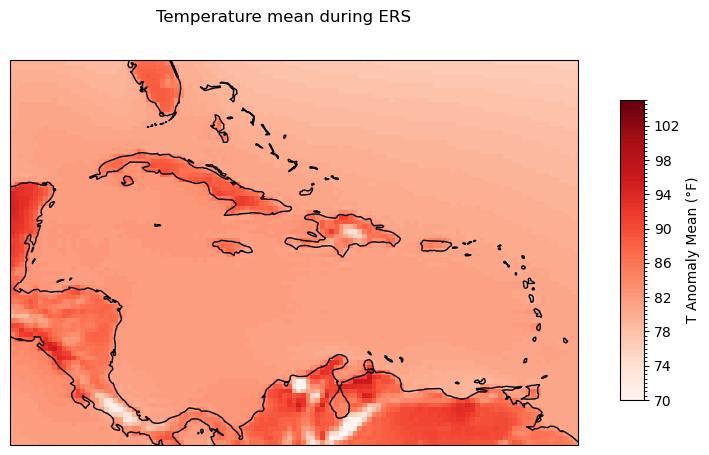

In [14]:
ERS_Tme_plot = ERS_Tme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(70, 105.5, 0.5), colors='Reds', subplot_kws={'projection': ccrs.PlateCarree()})

# UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
# UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=190)

ERS_Tme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = ERS_Tme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_Tme_plot, cax=cax, label='T Anomaly Mean (°F)', orientation='vertical', extend='neither')
# plt.quiverkey(UV_q, X=0.94, Y=0.15, U=10, label='10 m/s', labelpos='N', coordinates='figure')

plt.suptitle('Temperature mean during ERS')
plt.show()

# LRS

In [15]:
LRS = [8, 9, 10, 11]
LRS_HI = meHI_dmax.where(meHI_dmax.time.dt.month.isin(LRS), drop=True)
LRS_RH = meRH.where(meRH.time.dt.month.isin(LRS), drop=True)
LRS_T = meT.where(meT.time.dt.month.isin(LRS), drop=True)
LRS_UV = meUV.where(meUV.time.dt.month.isin(LRS), drop=True)

In [16]:
LRS_HIme = LRS_HI.mean('time')
LRS_RHme = LRS_RH.mean('time')
LRS_Tme = LRS_T.mean('time')
LRS_UVme = LRS_UV.mean('time')

## HI and UV

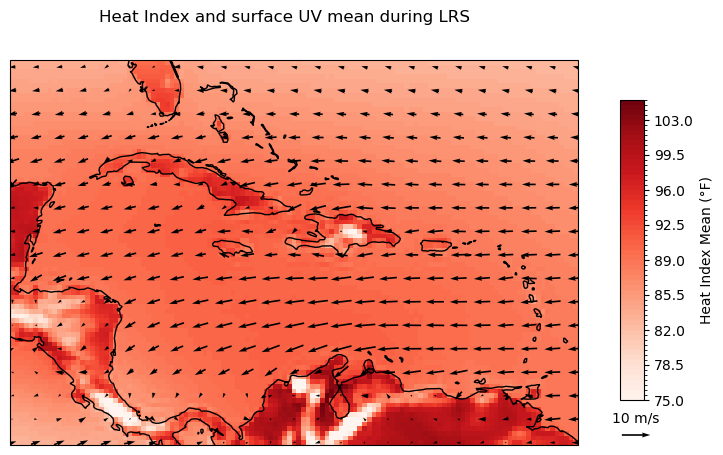

In [17]:
LRS_HIme_plot = LRS_HIme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(75, 105.5, 0.5), colors='Reds', subplot_kws={'projection': ccrs.PlateCarree()})

UV_coarse = LRS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=200)

LRS_HIme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = LRS_HIme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HIme_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=10, label='10 m/s', labelpos='N', coordinates='figure')

plt.suptitle('Heat Index and surface UV mean during LRS')
plt.show()

## RH

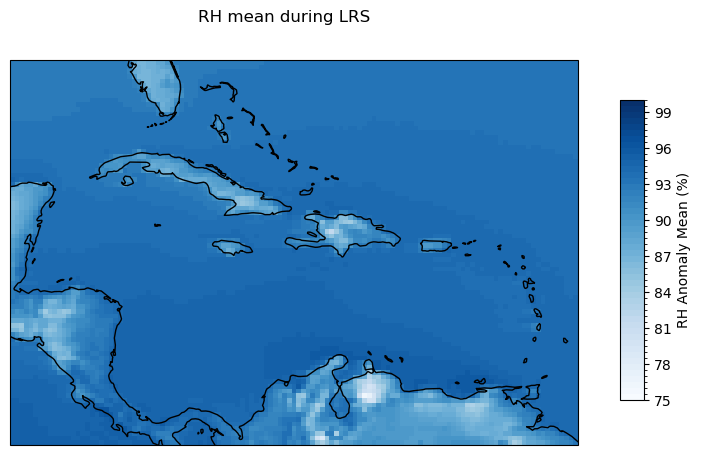

In [18]:
LRS_RHme_plot = LRS_RHme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(75, 100.5, 0.5), colors='Blues', subplot_kws={'projection': ccrs.PlateCarree()})

# UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
# UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=190)

LRS_RHme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = LRS_RHme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RHme_plot, cax=cax, label='RH Anomaly Mean (%)', orientation='vertical', extend='neither')
# plt.quiverkey(UV_q, X=0.94, Y=0.15, U=10, label='10 m/s', labelpos='N', coordinates='figure')
plt.suptitle('RH mean during LRS')
plt.show()

## T

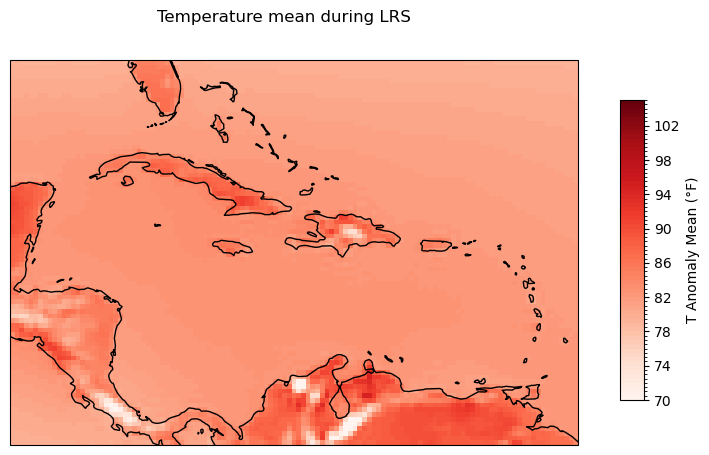

In [19]:
LRS_Tme_plot = LRS_Tme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(70, 105.5, 0.5), colors='Reds', subplot_kws={'projection': ccrs.PlateCarree()})

# UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
# UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=190)

LRS_Tme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = LRS_Tme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_Tme_plot, cax=cax, label='T Anomaly Mean (°F)', orientation='vertical', extend='neither')
# plt.quiverkey(UV_q, X=0.94, Y=0.15, U=10, label='10 m/s', labelpos='N', coordinates='figure')
plt.suptitle('Temperature mean during LRS')
plt.show()